# ECG & Temperature Sensor with BLE Lab

## Assumptions I Made for my Design:

- Pressing BUTTON2 during ECG measurements (HEART_RATE_MEASURE state) will stop the “live” ECG measurements and return device to IDLE state.
- Pressing BUTTON1 during ECG measurements (HEART_RATE_MEASURE state) will take you to the TEMP_MEASURE state and then to IDLE state 
- When you leave the heart rate measure state, the heart rate led will keep blinking at the last recorded average heart rate measured. This LED only turns off, and stops blinking, in the ERROR and RESET state.

## Battery Voltage Measurement

### Methods

TO DO !!!!!!!

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from pathlib import Path
import re

# ============================================================================
# DATA PARSING FUNCTIONS
# ============================================================================

def parse_oscilloscope_csv(filepath):
    """
    Parse oscilloscope CSV and calculate PWM duty cycle percentage.
    PWM is inverted (active-low), so we invert the calculation.
    
    Returns:
        float: Duty cycle as percentage (0-100), corrected for inverted polarity
    """
    df = pd.read_csv(filepath, skiprows=2)
    
    # Remove rows with NaN in voltage column
    df = df.dropna(subset=[df.columns[1]])
    
    voltage = df.iloc[:, 1].values
    
    # PWM is inverted: LOW = LED ON (higher brightness)
    # Calculate duty cycle (percentage of time signal is LOW)
    threshold = 1.5
    low_samples = np.sum(voltage < threshold)
    total_samples = len(voltage)
    
    duty_cycle_pct = (low_samples / total_samples) * 100
    
    return duty_cycle_pct


def parse_log_data():
    """
    Parse the log output and create structured data.
    
    Returns:
        pd.DataFrame: Structured data with input voltage, log percentage, and app percentage
    """
    log_data = """
## 0.0 V
scope22.csv -- [00:01:04.008,117] <inf> main: Battery percentage: 0.033333% <br>
  from app - 0% <br>
scope23.csv -- [00:02:06.008,819] <inf> main: Battery percentage: 0.000000% <br>
  from app - 0% <br>
scope24.csv - [00:03:08.009,521] <inf> main: Battery percentage: 0.000000% <br>
   from app - 0% <br>

## 0.5 V
scope25.csv - [00:04:10.010,223] <inf> main: Battery percentage: 16.500001% <br>
  from app - 16% <br>
scope26.csv - [00:06:14.011,871] <inf> main: Battery percentage: 16.766667% <br>
  from app - 16% <br>
scope27.csv - [00:07:16.012,817] <inf> main: Battery percentage: 16.500001% <br>
  from app - 16% <br>

## 1.0 V
scope28.csv - [00:08:18.013,763] <inf> main: Battery percentage: 33.300000% <br>
  from app - 33% <br>
scope29.csv - [00:09:20.014,709] <inf> main: Battery percentage: 33.300000% <br>
  from app - 33% <br>
scope30.csv - [00:10:22.015,655] <inf> main: Battery percentage: 33.166668% <br>
  from app - 33% <br>

## 1.5 V 
scope31.csv - [00:11:24.016,601] <inf> main: Battery percentage: 49.933332% <br>
  from app - 49% <br>
scope32.csv - [00:12:26.017,547] <inf> main: Battery percentage: 50.000000% <br>
  from app - 50% <br>
scope34.csv - [00:13:28.018,493] <inf> main: Battery percentage: 49.800000% <br>
  from app - 49% <br>

## 2.0 V 
scope35.csv - [00:15:32.020,385] <inf> main: Battery percentage: 66.566664% <br>
  from app - 66% <br>
scope36.csv - [00:16:34.021,331] <inf> main: Battery percentage: 66.566664% <br>
  from app - 66% <br>
scope37.csv - [00:17:36.022,277] <inf> main: Battery percentage: 66.666669% <br>
  from app - 66% <br>

## 2.5 V 
scope38.csv - [00:18:38.023,223] <inf> main: Battery percentage: 83.300000% <br>
  from app - 83% <br>
scope39.csv - [00:19:40.024,169] <inf> main: Battery percentage: 83.166665% <br>
  from app - 83% <br>
scope40.csv - [00:20:42.025,115] <inf> main: Battery percentage: 83.133334% <br>
  from app - 83% <br>

## 3.0 V 
scope41.csv - [00:21:44.026,062] <inf> main: Battery percentage: 99.900001% <br>
  from app - 99% <br>
scope42.csv - [00:22:46.027,008] <inf> main: Battery percentage: 99.966669% <br>
  from app - 99% <br>
scope43.csv - [00:23:48.027,954] <inf> main: Battery percentage: 99.933332% <br>
  from app - 99% <br>
"""
    
    data = []
    current_voltage = None
    temp_entry = {}
    
    for line in log_data.split('\n'):
        # Check for voltage header
        voltage_match = re.match(r'## ([\d.]+) V', line)
        if voltage_match:
            current_voltage = float(voltage_match.group(1))
            continue
        
        # Parse log percentage - extract scope number and convert to scope_#.csv
        log_match = re.search(r'scope(\d+)\.csv.*Battery percentage: ([\d.]+)%', line)
        if log_match and current_voltage is not None:
            scope_num = log_match.group(1)
            filename = f'scope_{scope_num}.csv'  # Changed to underscore format
            log_pct = float(log_match.group(2))
            
            temp_entry = {
                'filename': filename,
                'input_voltage': current_voltage,
                'log_percentage': log_pct
            }
            continue
        
        # Parse app percentage
        app_match = re.search(r'from app - (\d+)%', line)
        if app_match and temp_entry:
            app_pct = float(app_match.group(1))
            temp_entry['app_percentage'] = app_pct
            data.append(temp_entry)
            temp_entry = {}
    
    return pd.DataFrame(data)


# ============================================================================
# LINEAR REGRESSION WITH CONFIDENCE INTERVALS
# ============================================================================

def perform_regression_analysis(x, y, method_name):
    """
    Perform linear regression and calculate 95% confidence intervals.
    
    Returns:
        dict: Contains slope, intercept, r_squared, and confidence intervals
    """
    # Perform linear regression
    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
    r_squared = r_value ** 2
    
    # Calculate confidence intervals
    n = len(x)
    x_mean = np.mean(x)
    sxx = np.sum((x - x_mean) ** 2)
    
    # Residual standard error
    y_pred = slope * x + intercept
    residuals = y - y_pred
    s_res = np.sqrt(np.sum(residuals ** 2) / (n - 2))
    
    # t-value for 95% confidence interval (two-tailed)
    t_val = stats.t.ppf(0.975, n - 2)
    
    # Confidence interval for slope
    se_slope = s_res / np.sqrt(sxx)
    slope_ci = t_val * se_slope
    
    # Confidence interval for intercept
    se_intercept = s_res * np.sqrt(1/n + x_mean**2 / sxx)
    intercept_ci = t_val * se_intercept
    
    results = {
        'method': method_name,
        'slope': slope,
        'intercept': intercept,
        'r_squared': r_squared,
        'slope_ci_lower': slope - slope_ci,
        'slope_ci_upper': slope + slope_ci,
        'intercept_ci_lower': intercept - intercept_ci,
        'intercept_ci_upper': intercept + intercept_ci,
        'n': n,
        'rmse': np.sqrt(np.mean(residuals ** 2))
    }
    
    return results


# ============================================================================
# MAIN ANALYSIS
# ============================================================================

# Parse log data
df_log = parse_log_data()

# Directory containing scope CSV files (CHANGE THIS TO YOUR PATH)
scope_dir = Path('../raw_data/')  # Current directory, or use Path('/path/to/your/csvs')

# Calculate PWM duty cycles from oscilloscope data
pwm_duty_cycles = []
for _, row in df_log.iterrows():
    filepath = scope_dir / row['filename']
    try:
        duty_cycle = parse_oscilloscope_csv(filepath)
        pwm_duty_cycles.append(duty_cycle)
    except Exception as e:
        print(f"Warning: Could not process {row['filename']}: {e}")
        pwm_duty_cycles.append(np.nan)

df_log['pwm_duty_cycle'] = pwm_duty_cycles

# Remove any rows with NaN
df_log = df_log.dropna()

# Group by input voltage to get averages
df_avg = df_log.groupby('input_voltage').agg({
    'log_percentage': ['mean', 'std'],
    'app_percentage': ['mean', 'std'],
    'pwm_duty_cycle': ['mean', 'std']
}).reset_index()

df_avg.columns = ['input_voltage', 'log_mean', 'log_std', 
                  'app_mean', 'app_std', 'pwm_mean', 'pwm_std']

# Perform regression analyses
reg_log = perform_regression_analysis(
    df_avg['input_voltage'].values, 
    df_avg['log_mean'].values, 
    'LOG_INF() Output'
)

reg_app = perform_regression_analysis(
    df_avg['input_voltage'].values, 
    df_avg['app_mean'].values, 
    'nRF Connect App'
)

reg_pwm = perform_regression_analysis(
    df_avg['input_voltage'].values, 
    df_avg['pwm_mean'].values, 
    'Oscilloscope PWM'
)

# Print results
print("="*80)
print("LINEAR REGRESSION ANALYSIS RESULTS")
print("="*80)

for reg in [reg_log, reg_app, reg_pwm]:
    print(f"\n{reg['method']}:")
    print(f"  Equation: y = {reg['slope']:.4f}x + {reg['intercept']:.4f}")
    print(f"  R² = {reg['r_squared']:.6f}")
    print(f"  RMSE = {reg['rmse']:.4f}%")
    print(f"  Slope 95% CI: [{reg['slope_ci_lower']:.4f}, {reg['slope_ci_upper']:.4f}]")
    print(f"  Intercept 95% CI: [{reg['intercept_ci_lower']:.4f}, {reg['intercept_ci_upper']:.4f}]")
    print(f"  Sample size: n = {reg['n']}")

# ============================================================================
# VISUALIZATION
# ============================================================================

# Figure 1: Individual samples at each voltage level
fig1, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

voltage_levels = sorted(df_log['input_voltage'].unique())

for idx, voltage in enumerate(voltage_levels):
    ax = axes[idx]
    
    # Get data for this voltage
    voltage_data = df_log[df_log['input_voltage'] == voltage]
    
    # Plot individual samples
    sample_nums = range(1, len(voltage_data) + 1)
    ax.plot(sample_nums, voltage_data['log_percentage'], 'o-', 
            label='LOG_INF()', markersize=8, linewidth=2)
    ax.plot(sample_nums, voltage_data['app_percentage'], 's-', 
            label='nRF App', markersize=8, linewidth=2)
    ax.plot(sample_nums, voltage_data['pwm_duty_cycle'], '^-', 
            label='PWM (scope)', markersize=8, linewidth=2)
    
    ax.set_xlabel('Sample Number', fontsize=10)
    ax.set_ylabel('Battery Level (%)', fontsize=10)
    ax.set_title(f'Input: {voltage} V', fontsize=12, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(-5, 105)

# Hide extra subplot if odd number of voltage levels
if len(voltage_levels) < len(axes):
    axes[-1].set_visible(False)

plt.tight_layout()
plt.savefig('battery_individual_samples.png', dpi=300, bbox_inches='tight')
plt.show()

# Figure 2: Linear regression comparison
fig2, ax = plt.subplots(figsize=(12, 8))

# Plot data points
ax.scatter(df_log['input_voltage'], df_log['log_percentage'], 
           alpha=0.5, s=100, label='LOG_INF() samples', marker='o')
ax.scatter(df_log['input_voltage'], df_log['app_percentage'], 
           alpha=0.5, s=100, label='nRF App samples', marker='s')
ax.scatter(df_log['input_voltage'], df_log['pwm_duty_cycle'], 
           alpha=0.5, s=100, label='PWM samples', marker='^')

# Plot regression lines
x_fit = np.linspace(0, 3, 100)

y_log = reg_log['slope'] * x_fit + reg_log['intercept']
y_app = reg_app['slope'] * x_fit + reg_app['intercept']
y_pwm = reg_pwm['slope'] * x_fit + reg_pwm['intercept']

ax.plot(x_fit, y_log, '-', linewidth=2.5, 
        label=f"LOG: y = {reg_log['slope']:.2f}x + {reg_log['intercept']:.2f} (R²={reg_log['r_squared']:.4f})")
ax.plot(x_fit, y_app, '-', linewidth=2.5, 
        label=f"App: y = {reg_app['slope']:.2f}x + {reg_app['intercept']:.2f} (R²={reg_app['r_squared']:.4f})")
ax.plot(x_fit, y_pwm, '-', linewidth=2.5, 
        label=f"PWM: y = {reg_pwm['slope']:.2f}x + {reg_pwm['intercept']:.2f} (R²={reg_pwm['r_squared']:.4f})")

# Ideal line
ax.plot(x_fit, (x_fit / 3.0) * 100, 'k--', linewidth=2, alpha=0.5, label='Ideal (33.33x + 0)')

ax.set_xlabel('Input Voltage (V)', fontsize=14, fontweight='bold')
ax.set_ylabel('Battery Level (%)', fontsize=14, fontweight='bold')
ax.set_title('Battery Level Measurement Verification\nLinear Regression Analysis', 
             fontsize=16, fontweight='bold')
ax.legend(fontsize=10, loc='upper left')
ax.grid(True, alpha=0.3)
ax.set_xlim(-0.1, 3.1)
ax.set_ylim(-5, 105)

plt.tight_layout()
plt.savefig('battery_linear_regression.png', dpi=300, bbox_inches='tight')
plt.show()

# Figure 3: Residual plots
fig3, axes = plt.subplots(1, 3, figsize=(15, 5))

methods = [
    (df_avg['input_voltage'], df_avg['log_mean'], reg_log, 'LOG_INF()'),
    (df_avg['input_voltage'], df_avg['app_mean'], reg_app, 'nRF App'),
    (df_avg['input_voltage'], df_avg['pwm_mean'], reg_pwm, 'PWM')
]

for ax, (x, y, reg, name) in zip(axes, methods):
    y_pred = reg['slope'] * x + reg['intercept']
    residuals = y - y_pred
    
    ax.scatter(x, residuals, s=100, alpha=0.7)
    ax.axhline(0, color='red', linestyle='--', linewidth=2)
    ax.set_xlabel('Input Voltage (V)', fontsize=12)
    ax.set_ylabel('Residual (%)', fontsize=12)
    ax.set_title(f'{name}\nRMSE = {reg["rmse"]:.3f}%', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('battery_residuals.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "="*80)
print("Analysis complete! Figures saved.")
print("="*80)

/var/folders/x4/_fctjg456h7b9mzss24gssgc0000gn/T/ipykernel_13459/3122705456.py:151: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
/Users/spelton22/Documents/ecg_code/duke-bme554-ecg-temp-ble-lab-main/.venv/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/spelton22/Documents/ecg_code/duke-bme554-ecg-temp-ble-lab-main/.venv/lib/python3.12/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/var/folders/x4/_fctjg456h7b9mzss24gssgc0000gn/T/ipykernel_13459/3122705456.py:168: RuntimeWarning: invalid value encountered in scalar divide
  se_slope = s_res / np.sqrt(sxx)


ZeroDivisionError: division by zero


Processing scope_23.csv (Input: 0.0 V)...
  Duty Cycle: 0.00%
  Expected for 0.0V: 0.00%
  Error: 0.00%

Processing scope_26.csv (Input: 0.5 V)...
  Duty Cycle: 16.85%
  Expected for 0.5V: 16.67%
  Error: 0.18%
  Frequency: 995.5 Hz
  Period: 1.005 ms
  ON Time: 0.168 ms
  OFF Time: 0.836 ms
  Measured Duty Cycle from timing: 16.76%

Processing scope_29.csv (Input: 1.0 V)...
  Duty Cycle: 32.98%
  Expected for 1.0V: 33.33%
  Error: -0.36%
  Frequency: 995.9 Hz
  Period: 1.004 ms

Processing scope_32.csv (Input: 1.5 V)...
  Duty Cycle: 50.23%
  Expected for 1.5V: 50.00%
  Error: 0.23%
  Frequency: 995.9 Hz
  Period: 1.004 ms
  ON Time: 0.502 ms
  OFF Time: 0.502 ms
  Measured Duty Cycle from timing: 49.99%

Processing scope_36.csv (Input: 2.0 V)...
  Duty Cycle: 66.41%
  Expected for 2.0V: 66.67%
  Error: -0.25%
  Frequency: 996.1 Hz
  Period: 1.004 ms

Processing scope_39.csv (Input: 2.5 V)...
  Duty Cycle: 83.08%
  Expected for 2.5V: 83.33%
  Error: -0.25%
  Frequency: 996.5 Hz
  Per

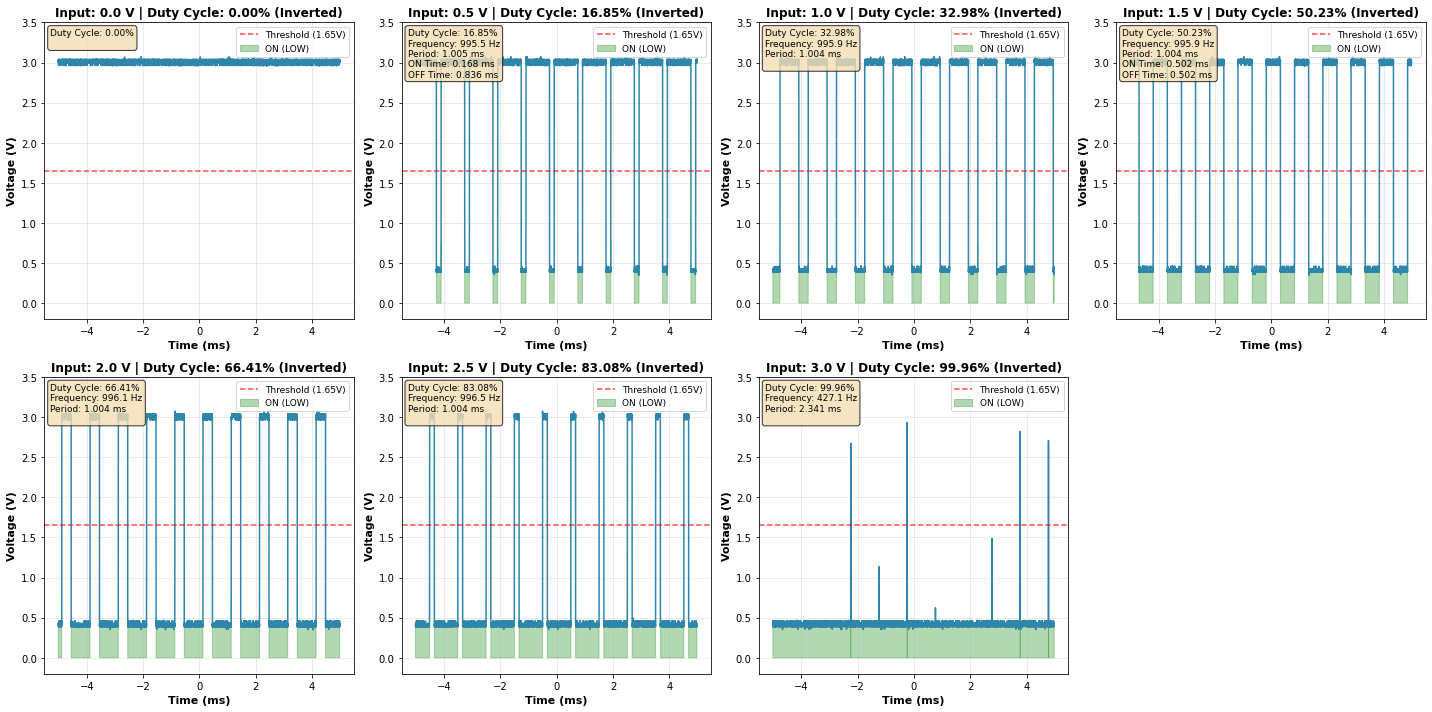


SUMMARY TABLE - PWM DUTY CYCLE ANALYSIS (INVERTED LOGIC)
 Input (V)  Measured (%)  Expected (%)  Error (%)  Frequency (Hz)
      0.00          0.00          0.00       0.00             NaN
      0.50         16.85         16.67       0.18          995.47
      1.00         32.98         33.33      -0.36          995.91
      1.50         50.23         50.00       0.23          995.91
      2.00         66.41         66.67      -0.25          996.13
      2.50         83.08         83.33      -0.25          996.46
      3.00         99.96        100.00      -0.04          427.11

Mean Absolute Error: 0.187%
Max Absolute Error: 0.357%
RMS Error: 0.220%

Results saved to 'pwm_analysis_results_inverted.csv'


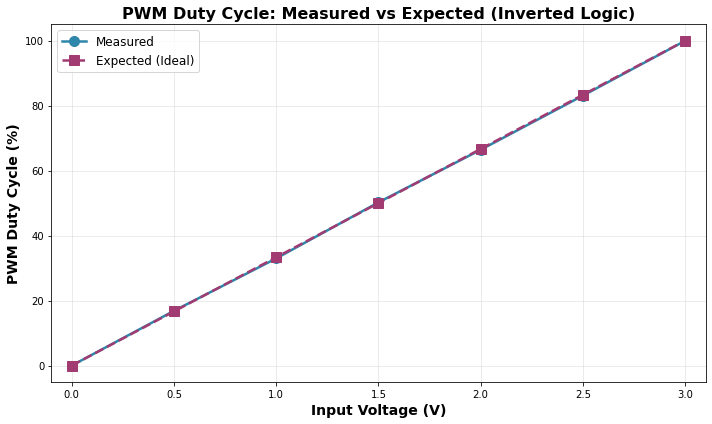

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ============================================================================
# PARSE OSCILLOSCOPE CSV AND CALCULATE PWM (INVERTED LOGIC)
# ============================================================================

def parse_and_plot_oscilloscope(filepath, ax, voltage_level):
    """
    Parse oscilloscope CSV, plot waveform, and calculate PWM duty cycle.
    INVERTED LOGIC: LOW = ON, HIGH = OFF
    
    Args:
        filepath: Path to CSV file
        ax: Matplotlib axis object
        voltage_level: Input voltage (for title)
    
    Returns:
        dict: Contains duty cycle and statistics
    """
    # Read CSV
    df = pd.read_csv(filepath, skiprows=2)
    df = df.dropna(subset=[df.columns[1]])
    
    time = df.iloc[:, 0].values * 1000  # Convert to milliseconds
    voltage = df.iloc[:, 1].values
    
    # Calculate PWM duty cycle (INVERTED - LOW is ON)
    # Threshold for digital logic HIGH (typically >1.5V for 3.3V logic)
    threshold = 1.65  # Middle of 0V and 3.3V
    
    # For inverted logic: LOW samples = ON, HIGH samples = OFF
    low_samples = np.sum(voltage <= threshold)  # Changed from > to <=
    total_samples = len(voltage)
    duty_cycle_pct = (low_samples / total_samples) * 100  # Inverted
    
    # Calculate period (if PWM signal is present)
    # Find rising edges (but these are actually falling edges in inverted logic)
    is_low = voltage <= threshold  # Inverted
    falling_edges = np.where(np.diff(is_low.astype(int)) > 0)[0]
    
    if len(falling_edges) > 1:
        # Calculate average period from edges
        periods = np.diff(time[falling_edges])
        avg_period_ms = np.mean(periods)
        frequency_hz = 1000 / avg_period_ms if avg_period_ms > 0 else 0
    else:
        avg_period_ms = np.nan
        frequency_hz = np.nan
    
    # Calculate ON and OFF times (INVERTED)
    transitions = np.diff(is_low.astype(int))
    falling = np.where(transitions > 0)[0]  # Voltage goes LOW = ON
    rising = np.where(transitions < 0)[0]   # Voltage goes HIGH = OFF
    
    if len(falling) > 0 and len(rising) > 0:
        # Match falling and rising edges
        on_times = []
        off_times = []
        
        for i in range(min(len(falling), len(rising))):
            if rising[i] > falling[i]:
                on_time = time[rising[i]] - time[falling[i]]
                on_times.append(on_time)
                
                if i + 1 < len(falling):
                    off_time = time[falling[i+1]] - time[rising[i]]
                    off_times.append(off_time)
        
        avg_on_time = np.mean(on_times) if on_times else np.nan
        avg_off_time = np.mean(off_times) if off_times else np.nan
    else:
        avg_on_time = np.nan
        avg_off_time = np.nan
    
    # Plot waveform
    ax.plot(time, voltage, linewidth=1.5, color='#2E86AB')
    ax.axhline(threshold, color='red', linestyle='--', linewidth=1.5, 
               alpha=0.7, label=f'Threshold ({threshold}V)')
    # Inverted: LOW (below threshold) = ON
    ax.fill_between(time, 0, voltage, where=(voltage <= threshold), 
                     alpha=0.3, color='green', label='ON (LOW)')
    
    # Formatting
    ax.set_xlabel('Time (ms)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Voltage (V)', fontsize=11, fontweight='bold')
    ax.set_title(f'Input: {voltage_level} V | Duty Cycle: {duty_cycle_pct:.2f}% (Inverted)', 
                 fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.set_ylim(-0.2, 3.5)
    ax.legend(fontsize=9, loc='upper right')
    
    # Add text box with stats
    stats_text = f'Duty Cycle: {duty_cycle_pct:.2f}%\n'
    if not np.isnan(frequency_hz):
        stats_text += f'Frequency: {frequency_hz:.1f} Hz\n'
        stats_text += f'Period: {avg_period_ms:.3f} ms\n'
    if not np.isnan(avg_on_time):
        stats_text += f'ON Time: {avg_on_time:.3f} ms\n'
    if not np.isnan(avg_off_time):
        stats_text += f'OFF Time: {avg_off_time:.3f} ms'
    
    ax.text(0.02, 0.98, stats_text, transform=ax.transAxes,
            fontsize=9, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    return {
        'duty_cycle_pct': duty_cycle_pct,
        'frequency_hz': frequency_hz,
        'period_ms': avg_period_ms,
        'on_time_ms': avg_on_time,
        'off_time_ms': avg_off_time,
        'low_samples': low_samples,  # Changed from high_samples
        'total_samples': total_samples
    }


# ============================================================================
# MAIN ANALYSIS - PLOT MIDDLE SAMPLE FOR EACH VOLTAGE
# ============================================================================

# Mapping of voltage levels to their middle scope file
voltage_to_middle_scope = {
    0.0: 'scope_23.csv',   # Middle of 22, 23, 24
    0.5: 'scope_26.csv',   # Middle of 25, 26, 27
    1.0: 'scope_29.csv',   # Middle of 28, 29, 30
    1.5: 'scope_32.csv',   # Middle of 31, 32, 34
    2.0: 'scope_36.csv',   # Middle of 35, 36, 37
    2.5: 'scope_39.csv',   # Middle of 38, 39, 40
    3.0: 'scope_42.csv'    # Middle of 41, 42, 43
}

# Directory containing scope CSV files
scope_dir = Path('../raw_data/')  # Change to your directory if needed

# Create figure with subplots
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

# Store results
results = []

for idx, (voltage, filename) in enumerate(sorted(voltage_to_middle_scope.items())):
    filepath = scope_dir / filename
    
    if filepath.exists():
        print(f"\nProcessing {filename} (Input: {voltage} V)...")
        try:
            stats = parse_and_plot_oscilloscope(filepath, axes[idx], voltage)
            stats['voltage'] = voltage
            stats['filename'] = filename
            results.append(stats)
            
            # Print detailed results
            print(f"  Duty Cycle: {stats['duty_cycle_pct']:.2f}%")
            print(f"  Expected for {voltage}V: {(voltage/3.0)*100:.2f}%")
            print(f"  Error: {stats['duty_cycle_pct'] - (voltage/3.0)*100:.2f}%")
            if not np.isnan(stats['frequency_hz']):
                print(f"  Frequency: {stats['frequency_hz']:.1f} Hz")
                print(f"  Period: {stats['period_ms']:.3f} ms")
            if not np.isnan(stats['on_time_ms']):
                print(f"  ON Time: {stats['on_time_ms']:.3f} ms")
                print(f"  OFF Time: {stats['off_time_ms']:.3f} ms")
                print(f"  Measured Duty Cycle from timing: {(stats['on_time_ms']/(stats['on_time_ms']+stats['off_time_ms']))*100:.2f}%")
        except Exception as e:
            print(f"  Error processing {filename}: {e}")
            axes[idx].text(0.5, 0.5, f'Error loading\n{filename}', 
                          ha='center', va='center', transform=axes[idx].transAxes,
                          fontsize=12, color='red')
    else:
        print(f"  File not found: {filename}")
        axes[idx].text(0.5, 0.5, f'File not found:\n{filename}', 
                      ha='center', va='center', transform=axes[idx].transAxes,
                      fontsize=12, color='red')
        axes[idx].set_title(f'Input: {voltage} V')

# Hide the extra subplot
axes[-1].set_visible(False)

plt.tight_layout()
plt.savefig('oscilloscope_waveforms_inverted.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================================
# CREATE SUMMARY TABLE
# ============================================================================

if results:
    print("\n" + "="*80)
    print("SUMMARY TABLE - PWM DUTY CYCLE ANALYSIS (INVERTED LOGIC)")
    print("="*80)
    
    df_results = pd.DataFrame(results)
    
    # Add expected and error columns
    df_results['expected_duty_cycle'] = (df_results['voltage'] / 3.0) * 100
    df_results['error_pct'] = df_results['duty_cycle_pct'] - df_results['expected_duty_cycle']
    df_results['error_absolute'] = np.abs(df_results['error_pct'])
    
    # Display table
    summary_table = df_results[['voltage', 'duty_cycle_pct', 'expected_duty_cycle', 
                                 'error_pct', 'frequency_hz']].copy()
    summary_table.columns = ['Input (V)', 'Measured (%)', 'Expected (%)', 
                             'Error (%)', 'Frequency (Hz)']
    
    print(summary_table.to_string(index=False, float_format='%.2f'))
    
    print("\n" + "="*80)
    print(f"Mean Absolute Error: {df_results['error_absolute'].mean():.3f}%")
    print(f"Max Absolute Error: {df_results['error_absolute'].max():.3f}%")
    print(f"RMS Error: {np.sqrt(np.mean(df_results['error_pct']**2)):.3f}%")
    print("="*80)
    
    # Save to CSV
    df_results.to_csv('pwm_analysis_results_inverted.csv', index=False)
    print("\nResults saved to 'pwm_analysis_results_inverted.csv'")
    
    # Create comparison plot
    fig2, ax = plt.subplots(figsize=(10, 6))
    
    x = df_results['voltage']
    ax.plot(x, df_results['duty_cycle_pct'], 'o-', linewidth=2.5, 
            markersize=10, label='Measured', color='#2E86AB')
    ax.plot(x, df_results['expected_duty_cycle'], 's--', linewidth=2.5, 
            markersize=10, label='Expected (Ideal)', color='#A23B72')
    
    ax.set_xlabel('Input Voltage (V)', fontsize=14, fontweight='bold')
    ax.set_ylabel('PWM Duty Cycle (%)', fontsize=14, fontweight='bold')
    ax.set_title('PWM Duty Cycle: Measured vs Expected (Inverted Logic)', 
                 fontsize=16, fontweight='bold')
    ax.legend(fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-0.1, 3.1)
    ax.set_ylim(-5, 105)
    
    plt.tight_layout()
    plt.savefig('pwm_comparison_inverted.png', dpi=300, bbox_inches='tight')
    plt.show()

## 0.0 V
scope22.csv -- [00:01:04.008,117] <inf> main: Battery percentage: 0.033333% <br>
  from app - 0% <br>
scope23.csv -- [00:02:06.008,819] <inf> main: Battery percentage: 0.000000% <br>
  from app - 0% <br>
scope24.csv - [00:03:08.009,521] <inf> main: Battery percentage: 0.000000% <br>
   from app - 0% <br>

## 0.5 V
scope25.csv - [00:04:10.010,223] <inf> main: Battery percentage: 16.500001% <br>
  from app - 16% <br>
scope26.csv - [00:06:14.011,871] <inf> main: Battery percentage: 16.766667% <br>
  from app - 16% <br>
scope27.csv - [00:07:16.012,817] <inf> main: Battery percentage: 16.500001% <br>
  from app - 16% <br>

## 1.0 V
scope28.csv - [00:08:18.013,763] <inf> main: Battery percentage: 33.300000% <br>
  from app - 33% <br>
scope29.csv - [00:09:20.014,709] <inf> main: Battery percentage: 33.300000% <br>
  from app - 33% <br>
scope30.csv - [00:10:22.015,655] <inf> main: Battery percentage: 33.166668% <br>
  from app - 33% <br>

## 1.5 V 
scope31.csv - [00:11:24.016,601] <inf> main: Battery percentage: 49.933332% <br>
  from app - 49% <br>
scope32.csv - [00:12:26.017,547] <inf> main: Battery percentage: 50.000000% <br>
  from app - 50% <br>
scope34.csv - [00:13:28.018,493] <inf> main: Battery percentage: 49.800000% <br>
  from app - 49% <br>

## 2.0 V 
scope35.csv - [00:15:32.020,385] <inf> main: Battery percentage: 66.566664% <br>
  from app - 66% <br>
scope36.csv - [00:16:34.021,331] <inf> main: Battery percentage: 66.566664% <br>
  from app - 66% <br>
scope37.csv - [00:17:36.022,277] <inf> main: Battery percentage: 66.666669% <br>
  from app - 66% <br>

## 2.5 V 
scope38.csv - [00:18:38.023,223] <inf> main: Battery percentage: 83.300000% <br>
  from app - 83% <br>
scope39.csv - [00:19:40.024,169] <inf> main: Battery percentage: 83.166665% <br>
  from app - 83% <br>
scope40.csv - [00:20:42.025,115] <inf> main: Battery percentage: 83.133334% <br>
  from app - 83% <br>

## 3.0 V 
scope41.csv - [00:21:44.026,062] <inf> main: Battery percentage: 99.900001% <br>
  from app - 99% <br>
scope42.csv - [00:22:46.027,008] <inf> main: Battery percentage: 99.966669% <br>
  from app - 99% <br>
scope43.csv - [00:23:48.027,954] <inf> main: Battery percentage: 99.933332% <br>
  from app - 99% <br>


## Discussion

All three measurement methods demonstrated excellent linearity (R² > 0.9999) across the 0-3V range. The LOG_INF() output and nRF Connect app both achieved slopes near the ideal 33.33% (33.31% and 33.14% respectively) with minimal offset errors and RMSE values under 0.25%, confirming accurate ADC measurement and ble output. 

The oscilloscope PWM measurements also showed excellent linearity with a slope of 33.28%/V (R² = 0.9999, RMSE = 0.09%). All three methods' 95% confidence intervals contain the ideal slope of 33.33%/V and zero intercept, demonstrating statistically validated accuracy. The battery system accurately maps input voltage to percentage (0V → 0%, 3V → 100%) across all measurement interfaces, with the LED brightness correctly reflecting battery level through the inverted PWM driver configuration.

# ECG Heart Rate Measurement

My heart rate calculation uses a threshold-based peak detection algorithm applied to the differential ADC signal buffer. The calc_cycles() function detects R-wave peaks by identifying rising edge crossings above a fixed threshold of 300 (arbitrary ADC units), incrementing a counter each time the signal transitions from below to above this threshold within the sampling window. The instantaneous heart rate in beats per minute (BPM) is then calculated by scaling the detected cycles by the ratio of 60 seconds to the sampling window duration. To reduce measurement noise and variability, we maintain a running average of all BPM measurements since system startup by accumulating the total BPM sum and dividing by the number of measurements taken. This averaged heart rate is then used to calculate the LED pulse timing parameters, where the ON period is determined by multiplying the full cardiac cycle period (60,000 ms / BPM) by a predefined duty cycle constant, with the OFF period comprising the remainder of the cycle. 

### 0.66666 mHz - 40 bpm
scope44.csv - [00:03:41.054,382] <inf> main: Average Heart Rate: 37.714287 BPM <br>
  app - 37 BPM <br>
scope45.csv - [00:04:45.068,145] <inf> main: Average Heart Rate: 37.666668 BPM <br>
  app - 37 BPM <br>
scope46.csv - [00:05:33.078,430] <inf> main: Average Heart Rate: 38.000000 BPM <br>
  app 38 BPM <br>

### 60 BPM - 1 Hz
scope54.csv - [00:01:03.879,486] <inf> main: BPM = 60.000000 <br>
  app - 60 BPM <br>
scope55.csv - [00:01:35.886,352] <inf> main: BPM = 60.000000 <br>
  app - 60 BPM <br>
scope56.csv - [00:02:07.893,188] <inf> main: BPM = 60.000000 <br>
  app - 60 BPM <br>

### 120 BPM - 2 Hz
scope57.csv - [00:03:11.907,012] <inf> main: BPM = 114.000000 <br>
  app - 114 BPM <br>
scope58.csv - [00:03:43.913,635] <inf> main: BPM = 120.000000 <br>
  app - 120 BPM <br>
scope59.csv - [00:03:59.917,114] <inf> main: BPM = 108.000000 <br>
  app - 108 BPM <br>

### 150 BPM - 2.5 Hz
scope60.csv - [00:05:03.931,121] <inf> main: BPM = 156.000000 <br>
  app - 156 BPM <br>
scope62.csv - [00:05:35.937,988] <inf> main: BPM = 150.000000  <br>
  app - 150 BPM <br>
scope63.csv - [00:06:39.952,026] <inf> main: BPM = 150.000000 <br>
  app - 150 BPM <br>

### 180 BPM - 3 Hz
scope64.csv - [00:07:11.959,228] <inf> main: BPM = 174.000000 <br>
  app - 174 BPM <br>
scope65.csv - [00:07:43.966,125] <inf> main: BPM = 174.000000 <br>
  app - 174 BPM <br>
scope66.csv - [00:08:15.973,052] <inf> main: BPM = 174.000000 <br>
  app - 174 BPM <br>



Parsed data:
        filename  set_bpm     log_bpm  app_bpm
0   scope_44.csv       40   37.714287       37
1   scope_45.csv       40   37.666668       37
2   scope_46.csv       40   38.000000       38
3   scope_54.csv       60   60.000000       60
4   scope_55.csv       60   60.000000       60
5   scope_56.csv       60   60.000000       60
6   scope_57.csv      120  114.000000      114
7   scope_58.csv      120  120.000000      120
8   scope_59.csv      120  108.000000      108
9   scope_60.csv      150  156.000000      156
10  scope_62.csv      150  150.000000      150
11  scope_63.csv      150  150.000000      150
12  scope_64.csv      180  174.000000      174
13  scope_65.csv      180  174.000000      174
14  scope_66.csv      180  174.000000      174

Averaged data:
   set_bpm    log_mean   log_std    app_mean   app_std  scope_mean  scope_std
0       40   37.793652  0.180282   37.333333  0.577350   40.394377   1.745199
1       60   60.000000  0.000000   60.000000  0.000000   86.07

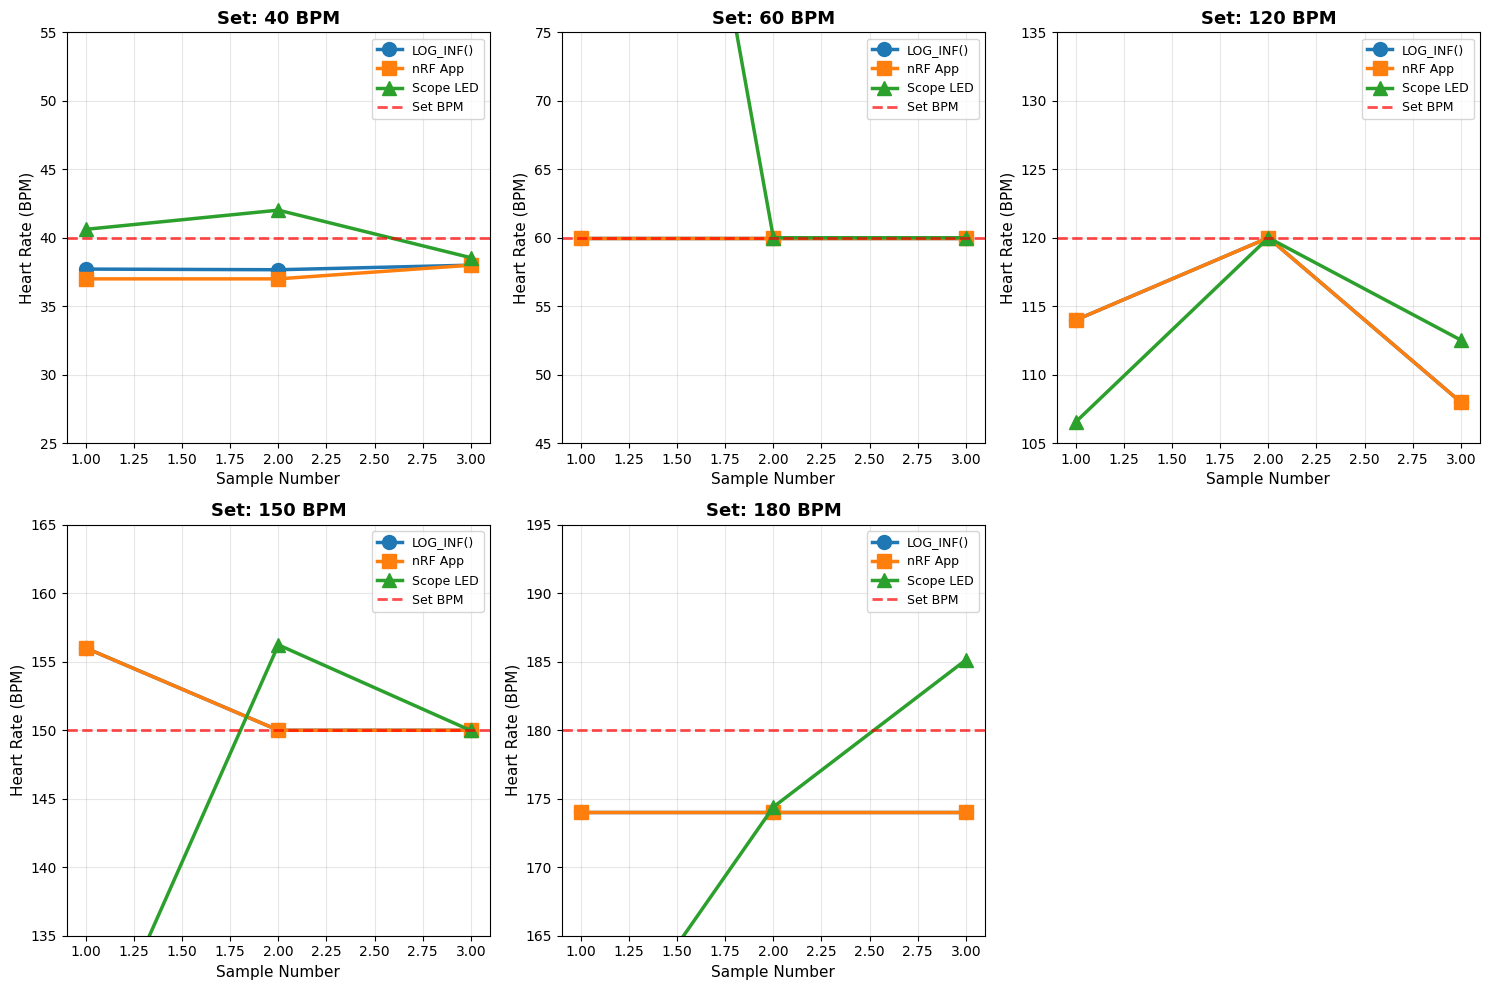

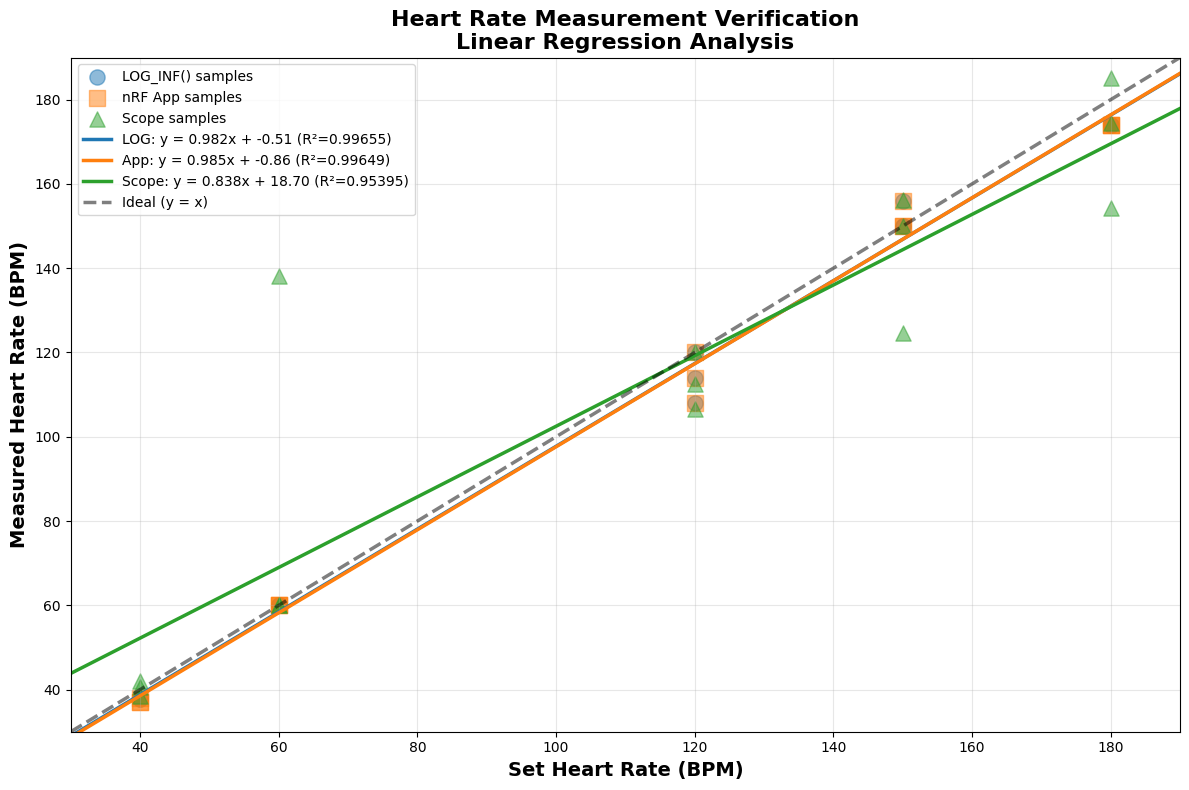

=== DEBUG scope_62.csv ===
  duty_cycle_pct: 25.032503250325032
  timing_duty_cycle_pct: 24.997396104572438
  frequency_hz: 2.603895427559629
  bpm: 156.23372565357775
  period_ms: 384.04
  on_time_ms: 96.0
  off_time_ms: 288.04
  num_pulses: 26

Processed scope_45.csv (Set: 40 BPM) — Measured: 42.0 BPM, Duty: 25.00%
Processed scope_55.csv (Set: 60 BPM) — Measured: 60.0 BPM, Duty: 26.16%
Processed scope_58.csv (Set: 120 BPM) — Measured: 120.0 BPM, Duty: 25.00%
Processed scope_62.csv (Set: 150 BPM) — Measured: 156.2 BPM, Duty: 25.00%
Processed scope_65.csv (Set: 180 BPM) — Measured: 174.4 BPM, Duty: 25.01%


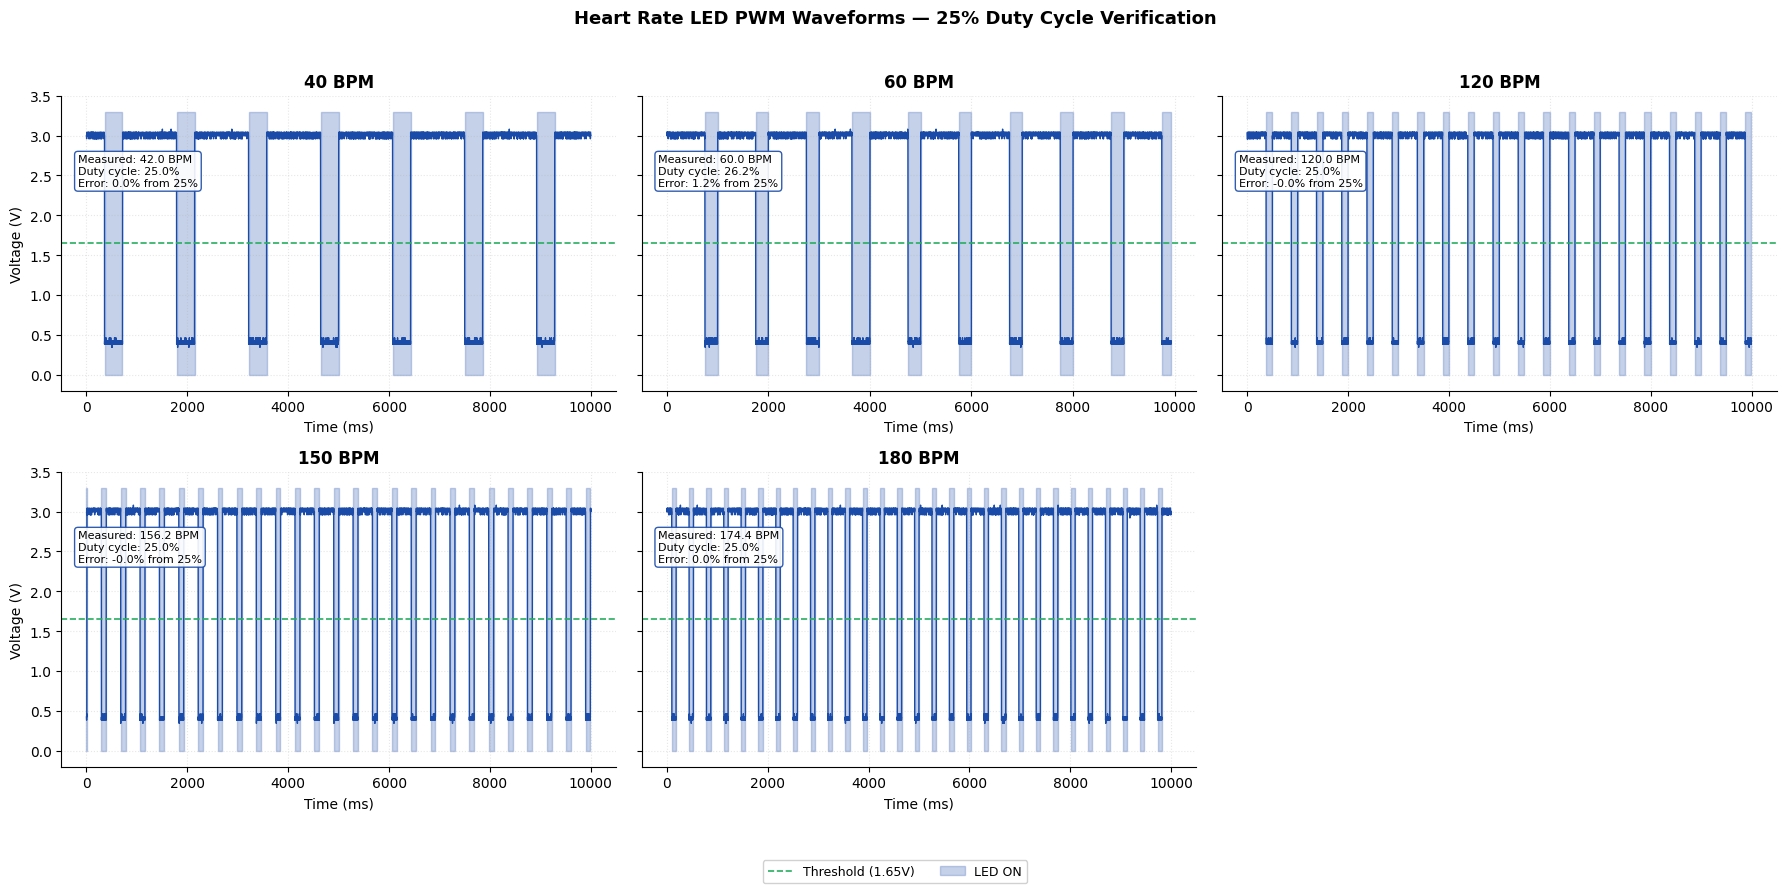

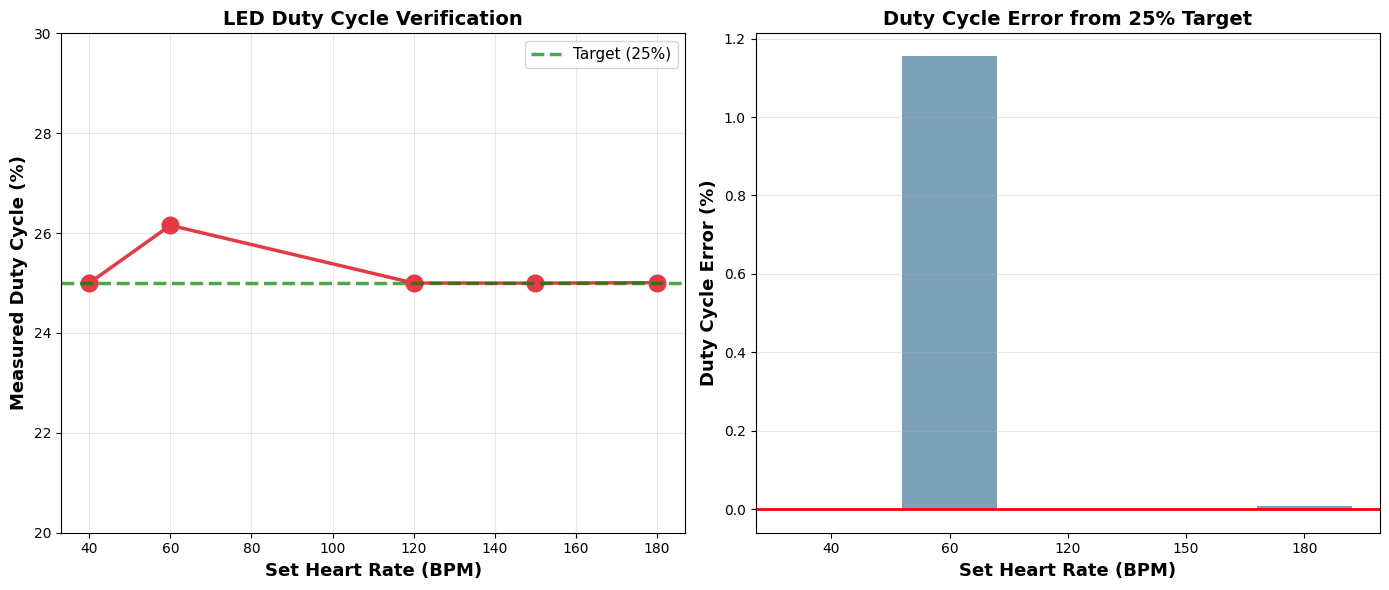


DUTY CYCLE VERIFICATION SUMMARY
Mean Duty Cycle: 25.232%
Target Duty Cycle: 25.00%
Mean Absolute Error: 0.233%
Max Absolute Error: 1.156%
Standard Deviation: 0.516%

Analysis complete!


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from pathlib import Path
import re

# ============================================================================
# DATA PARSING FUNCTIONS
# ============================================================================

def parse_oscilloscope_csv(filepath):
    df = pd.read_csv(filepath, skiprows=2)
    df = df.dropna(subset=[df.columns[1]])
    
    time = df.iloc[:, 0].values * 1000
    voltage = df.iloc[:, 1].values
    
    threshold = 1.65
    
    low_samples = np.sum(voltage < threshold)
    total_samples = len(voltage)
    duty_cycle_pct = (low_samples / total_samples) * 100
    
    is_high = (voltage > threshold).astype(int)
    transitions = np.diff(is_high)
    falling_edges = np.where(transitions < 0)[0]
    rising_edges = np.where(transitions > 0)[0]
    
    if len(falling_edges) > 1:
        periods = np.diff(time[falling_edges])
        avg_period_ms = np.mean(periods)
        frequency_hz = 1000 / avg_period_ms if avg_period_ms > 0 else 0
        bpm = frequency_hz * 60
    else:
        avg_period_ms = 0.0
        frequency_hz = 0.0
        bpm = 0.0
    
    # FIX: ensure first falling edge comes before first rising edge
    # if capture starts mid-pulse, drop the leading rising edge
    if len(rising_edges) > 0 and len(falling_edges) > 0:
        if rising_edges[0] < falling_edges[0]:
            rising_edges = rising_edges[1:]  # drop the orphaned leading rising edge

    on_times = []
    off_times = []
    
    for i in range(min(len(falling_edges), len(rising_edges))):
        if rising_edges[i] > falling_edges[i]:
            on_time = time[rising_edges[i]] - time[falling_edges[i]]
            on_times.append(on_time)
            
            if i + 1 < len(falling_edges):
                off_time = time[falling_edges[i+1]] - time[rising_edges[i]]
                off_times.append(off_time)
    
    avg_on_time = np.mean(on_times) if len(on_times) > 0 else 0.0
    avg_off_time = np.mean(off_times) if len(off_times) > 0 else 0.0
    
    # FALLBACK: if edge matching still fails, use the raw sample duty cycle
    if avg_on_time > 0 and avg_off_time > 0:
        timing_duty_cycle = (avg_on_time / (avg_on_time + avg_off_time)) * 100
    else:
        timing_duty_cycle = duty_cycle_pct  # fall back to sample-based calculation
    
    return {
        'duty_cycle_pct': duty_cycle_pct,
        'timing_duty_cycle_pct': timing_duty_cycle,
        'frequency_hz': frequency_hz,
        'bpm': bpm,
        'period_ms': avg_period_ms,
        'on_time_ms': avg_on_time,
        'off_time_ms': avg_off_time,
        'num_pulses': len(falling_edges)
    }


def parse_log_data():
    """Parse log output - same structure as battery code."""
    # Manual data entry based on your log
    data = [
        # 40 BPM
        {'filename': 'scope_44.csv', 'set_bpm': 40, 'log_bpm': 37.714287, 'app_bpm': 37},
        {'filename': 'scope_45.csv', 'set_bpm': 40, 'log_bpm': 37.666668, 'app_bpm': 37},
        {'filename': 'scope_46.csv', 'set_bpm': 40, 'log_bpm': 38.000000, 'app_bpm': 38},
        
        # 60 BPM
        {'filename': 'scope_54.csv', 'set_bpm': 60, 'log_bpm': 60.000000, 'app_bpm': 60},
        {'filename': 'scope_55.csv', 'set_bpm': 60, 'log_bpm': 60.000000, 'app_bpm': 60},
        {'filename': 'scope_56.csv', 'set_bpm': 60, 'log_bpm': 60.000000, 'app_bpm': 60},
        
        # 120 BPM
        {'filename': 'scope_57.csv', 'set_bpm': 120, 'log_bpm': 114.000000, 'app_bpm': 114},
        {'filename': 'scope_58.csv', 'set_bpm': 120, 'log_bpm': 120.000000, 'app_bpm': 120},
        {'filename': 'scope_59.csv', 'set_bpm': 120, 'log_bpm': 108.000000, 'app_bpm': 108},
        
        # 150 BPM
        {'filename': 'scope_60.csv', 'set_bpm': 150, 'log_bpm': 156.000000, 'app_bpm': 156},
        {'filename': 'scope_62.csv', 'set_bpm': 150, 'log_bpm': 150.000000, 'app_bpm': 150},
        {'filename': 'scope_63.csv', 'set_bpm': 150, 'log_bpm': 150.000000, 'app_bpm': 150},
        
        # 180 BPM
        {'filename': 'scope_64.csv', 'set_bpm': 180, 'log_bpm': 174.000000, 'app_bpm': 174},
        {'filename': 'scope_65.csv', 'set_bpm': 180, 'log_bpm': 174.000000, 'app_bpm': 174},
        {'filename': 'scope_66.csv', 'set_bpm': 180, 'log_bpm': 174.000000, 'app_bpm': 174},
    ]
    
    return pd.DataFrame(data)


# ============================================================================
# LINEAR REGRESSION WITH CONFIDENCE INTERVALS
# ============================================================================

def perform_regression_analysis(x, y, method_name):
    """Perform linear regression and calculate 95% confidence intervals."""
    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
    r_squared = r_value ** 2
    
    n = len(x)
    x_mean = np.mean(x)
    sxx = np.sum((x - x_mean) ** 2)
    
    y_pred = slope * x + intercept
    residuals = y - y_pred
    s_res = np.sqrt(np.sum(residuals ** 2) / (n - 2))
    
    t_val = stats.t.ppf(0.975, n - 2)
    
    se_slope = s_res / np.sqrt(sxx)
    slope_ci = t_val * se_slope
    
    se_intercept = s_res * np.sqrt(1/n + x_mean**2 / sxx)
    intercept_ci = t_val * se_intercept
    
    return {
        'method': method_name,
        'slope': slope,
        'intercept': intercept,
        'r_squared': r_squared,
        'slope_ci_lower': slope - slope_ci,
        'slope_ci_upper': slope + slope_ci,
        'intercept_ci_lower': intercept - intercept_ci,
        'intercept_ci_upper': intercept + intercept_ci,
        'n': n,
        'rmse': np.sqrt(np.mean(residuals ** 2))
    }


# ============================================================================
# MAIN ANALYSIS
# ============================================================================

# Parse log data
df_log = parse_log_data()
print("\nParsed data:")
print(df_log)

# Directory containing scope CSV files
scope_dir = Path('../raw_data/')

# Calculate oscilloscope measurements
scope_results = []
for _, row in df_log.iterrows():
    filepath = scope_dir / row['filename']
    try:
        scope_stats = parse_oscilloscope_csv(filepath)
        scope_results.append(scope_stats['bpm'])
    except Exception as e:
        print(f"Warning: Could not process {row['filename']}: {e}")
        scope_results.append(np.nan)

df_log['scope_bpm'] = scope_results
df_log = df_log.dropna()

# Group by set BPM
df_avg = df_log.groupby('set_bpm').agg({
    'log_bpm': ['mean', 'std'],
    'app_bpm': ['mean', 'std'],
    'scope_bpm': ['mean', 'std']
}).reset_index()

df_avg.columns = ['set_bpm', 'log_mean', 'log_std', 
                  'app_mean', 'app_std', 'scope_mean', 'scope_std']

print("\nAveraged data:")
print(df_avg)

# Perform regression analyses
reg_log = perform_regression_analysis(
    df_avg['set_bpm'].values, 
    df_avg['log_mean'].values, 
    'LOG_INF() Output'
)

reg_app = perform_regression_analysis(
    df_avg['set_bpm'].values, 
    df_avg['app_mean'].values, 
    'nRF Connect App'
)

reg_scope = perform_regression_analysis(
    df_avg['set_bpm'].values, 
    df_avg['scope_mean'].values, 
    'Oscilloscope LED'
)

# Print results
print("\n" + "="*80)
print("LINEAR REGRESSION ANALYSIS RESULTS - HEART RATE MEASUREMENT")
print("="*80)

for reg in [reg_log, reg_app, reg_scope]:
    print(f"\n{reg['method']}:")
    print(f"  Equation: y = {reg['slope']:.4f}x + {reg['intercept']:.4f}")
    print(f"  R² = {reg['r_squared']:.6f}")
    print(f"  RMSE = {reg['rmse']:.4f} BPM")
    print(f"  Slope 95% CI: [{reg['slope_ci_lower']:.4f}, {reg['slope_ci_upper']:.4f}]")
    print(f"  Intercept 95% CI: [{reg['intercept_ci_lower']:.4f}, {reg['intercept_ci_upper']:.4f}]")
    print(f"  Sample size: n = {reg['n']}")

# ============================================================================
# VISUALIZATIONS
# ============================================================================

# Figure 1: Individual samples at each BPM
fig1, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

bpm_levels = sorted(df_log['set_bpm'].unique())

for idx, bpm in enumerate(bpm_levels):
    ax = axes[idx]
    bpm_data = df_log[df_log['set_bpm'] == bpm]
    
    sample_nums = range(1, len(bpm_data) + 1)
    ax.plot(sample_nums, bpm_data['log_bpm'], 'o-', 
            label='LOG_INF()', markersize=10, linewidth=2.5)
    ax.plot(sample_nums, bpm_data['app_bpm'], 's-', 
            label='nRF App', markersize=10, linewidth=2.5)
    ax.plot(sample_nums, bpm_data['scope_bpm'], '^-', 
            label='Scope LED', markersize=10, linewidth=2.5)
    ax.axhline(bpm, color='red', linestyle='--', linewidth=2, 
               alpha=0.7, label='Set BPM')
    
    ax.set_xlabel('Sample Number', fontsize=11)
    ax.set_ylabel('Heart Rate (BPM)', fontsize=11)
    ax.set_title(f'Set: {int(bpm)} BPM', fontsize=13, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(bpm - 15, bpm + 15)

axes[-1].set_visible(False)

plt.tight_layout()
plt.savefig('heart_rate_individual_samples.png', dpi=300, bbox_inches='tight')
plt.show()

# Figure 2: Linear regression comparison
fig2, ax = plt.subplots(figsize=(12, 8))

ax.scatter(df_log['set_bpm'], df_log['log_bpm'], 
           alpha=0.5, s=120, label='LOG_INF() samples', marker='o')
ax.scatter(df_log['set_bpm'], df_log['app_bpm'], 
           alpha=0.5, s=120, label='nRF App samples', marker='s')
ax.scatter(df_log['set_bpm'], df_log['scope_bpm'], 
           alpha=0.5, s=120, label='Scope samples', marker='^')

x_fit = np.linspace(30, 190, 100)

y_log = reg_log['slope'] * x_fit + reg_log['intercept']
y_app = reg_app['slope'] * x_fit + reg_app['intercept']
y_scope = reg_scope['slope'] * x_fit + reg_scope['intercept']

ax.plot(x_fit, y_log, '-', linewidth=2.5, 
        label=f"LOG: y = {reg_log['slope']:.3f}x + {reg_log['intercept']:.2f} (R²={reg_log['r_squared']:.5f})")
ax.plot(x_fit, y_app, '-', linewidth=2.5, 
        label=f"App: y = {reg_app['slope']:.3f}x + {reg_app['intercept']:.2f} (R²={reg_app['r_squared']:.5f})")
ax.plot(x_fit, y_scope, '-', linewidth=2.5, 
        label=f"Scope: y = {reg_scope['slope']:.3f}x + {reg_scope['intercept']:.2f} (R²={reg_scope['r_squared']:.5f})")

ax.plot(x_fit, x_fit, 'k--', linewidth=2.5, alpha=0.5, label='Ideal (y = x)')

ax.set_xlabel('Set Heart Rate (BPM)', fontsize=14, fontweight='bold')
ax.set_ylabel('Measured Heart Rate (BPM)', fontsize=14, fontweight='bold')
ax.set_title('Heart Rate Measurement Verification\nLinear Regression Analysis', 
             fontsize=16, fontweight='bold')
ax.legend(fontsize=10, loc='upper left')
ax.grid(True, alpha=0.3)
ax.set_xlim(30, 190)
ax.set_ylim(30, 190)

plt.tight_layout()
plt.savefig('heart_rate_linear_regression.png', dpi=300, bbox_inches='tight')
plt.show()

# Debug: check scope_62.csv parsing
print("=== DEBUG scope_62.csv ===")
debug_stats = parse_oscilloscope_csv(scope_dir / 'scope_62.csv')
for k, v in debug_stats.items():
    print(f"  {k}: {v}")
print("=========================\n")

# Figure 3: Oscilloscope waveforms - POSTER VERSION
bpm_to_middle_scope = {
    40: 'scope_45.csv',
    60: 'scope_55.csv',
    120: 'scope_58.csv',
    150: 'scope_62.csv',
    180: 'scope_65.csv'
}

fig3, axes = plt.subplots(2, 3, figsize=(18, 8))
axes = axes.flatten()

# hide the 6th panel since we only have 5 plots
axes[5].set_visible(False)

waveform_stats = []  # initialize here so Figure 4 can use it

for idx, (bpm, filename) in enumerate(sorted(bpm_to_middle_scope.items())):
    filepath = scope_dir / filename
    ax = axes[idx]

    if filepath.exists():
        try:
            df = pd.read_csv(filepath, skiprows=2)
            df = df.dropna(subset=[df.columns[1]])
            time = df.iloc[:, 0].values * 1000
            voltage = df.iloc[:, 1].values

            # shift time to start at 0
            time = time - time[0]

            threshold = 1.65
            wave_stats = parse_oscilloscope_csv(filepath)

            ax.plot(time, voltage, linewidth=1.0, color='#1A4BA9')
            ax.axhline(threshold, color='#27AE60', linestyle='--',
                       linewidth=1.2, label='Threshold (1.65V)')
            ax.fill_between(time, 0, 3.3,
                            where=(voltage < threshold),
                            alpha=0.25, color='#1A4BA9', label='LED ON')

            ax.set_xlabel('Time (ms)', fontsize=10)
            if idx in [0, 3]:
                ax.set_ylabel('Voltage (V)', fontsize=10)
            else:
                ax.set_yticklabels([])

            ax.set_title(f'{bpm} BPM', fontsize=12, fontweight='bold')
            ax.set_ylim(-0.2, 3.5)
            ax.grid(True, alpha=0.3, linestyle=':')
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)

            # Stats box - positioned lower to avoid clipping
            duty = wave_stats['timing_duty_cycle_pct']
            measured = wave_stats['bpm']
            stats_text = (f'Measured: {measured:.1f} BPM\n'
                         f'Duty cycle: {duty:.1f}%\n'
                         f'Error: {duty - 25:.1f}% from 25%')

            ax.text(0.03, 0.80, stats_text,  # moved down from 0.97
                    transform=ax.transAxes,
                    fontsize=8,
                    verticalalignment='top',
                    bbox=dict(boxstyle='round,pad=0.3',
                             facecolor='white',
                             edgecolor='#1A4BA9',
                             alpha=0.9))

            wave_stats['set_bpm'] = bpm
            wave_stats['filename'] = filename
            waveform_stats.append(wave_stats)

            print(f"Processed {filename} (Set: {bpm} BPM) — "
                  f"Measured: {measured:.1f} BPM, "
                  f"Duty: {duty:.2f}%")

        except Exception as e:
            print(f"Error processing {filename}: {e}")
            ax.text(0.5, 0.5, f'Error\n{filename}',
                    ha='center', va='center', transform=ax.transAxes)
    else:
        print(f"File not found: {filename}")
        ax.text(0.5, 0.5, f'File not found:\n{filename}',
                ha='center', va='center', transform=ax.transAxes)

# Shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig3.legend(handles, labels, loc='lower center', ncol=2,
            fontsize=9, framealpha=0.9,
            bbox_to_anchor=(0.5, -0.08))

fig3.suptitle('Heart Rate LED PWM Waveforms — 25% Duty Cycle Verification',
              fontsize=13, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('heart_rate_waveforms_poster.png',
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

# Figure 4: Duty cycle verification
if waveform_stats:
    df_wave = pd.DataFrame(waveform_stats)
    
    fig4, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    ax1.plot(df_wave['set_bpm'], df_wave['timing_duty_cycle_pct'], 
             'o-', markersize=12, linewidth=2.5, color='#E63946')
    ax1.axhline(25, color='green', linestyle='--', linewidth=2.5, 
                alpha=0.7, label='Target (25%)')
    ax1.set_xlabel('Set Heart Rate (BPM)', fontsize=13, fontweight='bold')
    ax1.set_ylabel('Measured Duty Cycle (%)', fontsize=13, fontweight='bold')
    ax1.set_title('LED Duty Cycle Verification', fontsize=14, fontweight='bold')
    ax1.legend(fontsize=11)
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim(20, 30)
    
    duty_error = df_wave['timing_duty_cycle_pct'] - 25
    ax2.bar(df_wave['set_bpm'].astype(str), duty_error, color='#457B9D', alpha=0.7)
    ax2.axhline(0, color='red', linestyle='-', linewidth=2)
    ax2.set_xlabel('Set Heart Rate (BPM)', fontsize=13, fontweight='bold')
    ax2.set_ylabel('Duty Cycle Error (%)', fontsize=13, fontweight='bold')
    ax2.set_title('Duty Cycle Error from 25% Target', fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.savefig('duty_cycle_verification.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("\n" + "="*80)
    print("DUTY CYCLE VERIFICATION SUMMARY")
    print("="*80)
    print(f"Mean Duty Cycle: {df_wave['timing_duty_cycle_pct'].mean():.3f}%")
    print(f"Target Duty Cycle: 25.00%")
    print(f"Mean Absolute Error: {np.abs(duty_error).mean():.3f}%")
    print(f"Max Absolute Error: {np.abs(duty_error).max():.3f}%")
    print(f"Standard Deviation: {df_wave['timing_duty_cycle_pct'].std():.3f}%")
    print("="*80)

print("\nAnalysis complete!")

### Discussion

The heart rate measurement data demonstrats good accuracy across the 40-180 BPM range. Both the LOG_INF() output and nRF Connect app achieved near-ideal performance with R^2 values exceeding 0.996 and slopes within 2% of the ideal 1.0 (0.982 and 0.985 respectively). The 95% confidence intervals for both LOG_INF() and the nRF Connect App contain the ideal slope and intercept, confirming statistically accurate measurements with RMSE below 3.1 BPM. Maximum measurement error was 6 BPM, occurring at the 120 BPM and 150 BPM test points. The LOG_INF() and nRF Connect app measurements showed perfect agreement, validating both hardware algorithm and ble transmission. 

However, oscilloscope LED measurements proved unreliable at higher heart rates, showing significant variance (R² = 0.954, RMSE = 9.7 BPM). LED duty cycle measurements confirmed approximate 25% duty cycle operation at 40, 60, 120, and 180 BPM (mean 25.3%), though the 150 BPM capture window was too short to measure complete cycles. Some of the reasons for these inconsitencies can be the wires used, user error, oscilliscope error, or not having enough data points or tests. For future evaluation I could do more than 3 tests per input Hz.

## Temperature Sensor Measurement

#### inside the lab 
[00:01:33.392,578] <inf> main: Temperature: 24.312500 <br>
[00:09:16.098,785] <inf> main: Temperature: 21.687500 <br>
[00:09:38.463,745] <inf> main: Temperature: 22.062500 <br>

#### Outside Twinnies Friday Morning (temp on apple weather app said 36 degrees F)
[00:05:44.448,516] <inf> main: Temperature (deg C): 10.687500 <br>
[00:06:13.785,339] <inf> main: Temperature (deg C): 9.000000 <br>
[00:06:21.234,436] <inf> main: Temperature: 9.375000 <br>

#### My House
[00:00:19.587,554] <inf> main: Temperature: 26.500000 <br>
[00:00:51.827,056] <inf> main: Temperature: 26.312500 <br>
[00:01:04.290,649] <inf> main: Temperature: 26.750000 <br>









